In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/mricardo89/data-mining/main/Unit-III/datasets/players_data-2025_2026.csv"
df = pd.read_csv(url)

### Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)


In [3]:
df.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
count,2839.000000,2837.000000,2837.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,...,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000
mean,1420.000000,24.855834,1999.802256,19.138781,13.576611,1218.580134,13.539803,1.660444,1.159211,2.819655,...,2.412821,0.121169,0.041564,14.497710,13.752730,2.060937,21.657978,10.141951,11.924974,0.045791
std,819.693032,4.623789,4.633160,11.520385,11.225366,963.218994,10.703241,2.932688,1.833065,4.134442,...,2.526406,0.352339,0.204853,13.493894,14.665142,3.801657,34.963118,11.810994,12.430342,0.228399
min,1.000000,15.000000,1983.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,710.500000,21.000000,1997.000000,9.000000,3.000000,320.500000,3.600000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,1420.000000,25.000000,2000.000000,20.000000,12.000000,1074.000000,11.900000,0.000000,0.000000,1.000000,...,2.000000,0.000000,0.000000,12.000000,9.000000,1.000000,6.000000,5.000000,8.000000,0.000000
75%,2129.500000,28.000000,2003.000000,29.000000,23.000000,1972.500000,21.900000,2.000000,2.000000,4.000000,...,4.000000,0.000000,0.000000,23.000000,20.000000,2.500000,26.500000,16.000000,19.000000,0.000000
max,2839.000000,41.000000,2010.000000,38.000000,38.000000,3420.000000,38.000000,36.000000,21.000000,41.000000,...,13.000000,3.000000,2.000000,87.000000,118.000000,41.000000,295.000000,77.000000,72.000000,2.000000


In [4]:
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,3,0,0,20,51,5,37,17,27,0
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0,0,0,3,1,0,3,2,4,0
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,0,0,0,7,3,2,30,3,3,0
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,1,0,0,3,0,0,1,2,1,0


In [2]:
top_player = df.loc[df['Gls'].idxmax()]
print(top_player)

Rk                 1320
Player       Harry Kane
Nation          eng ENG
Pos               FW,MF
Squad     Bayern Munich
              ...      
Off                  20
Crs                  12
Int                   8
TklW                 13
OG                    0
Name: 1319, Length: 102, dtype: object


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2839 entries, 0 to 2838
Columns: 102 entries, Rk to OG
dtypes: float64(45), int64(40), object(17)
memory usage: 2.2+ MB


In [4]:
df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY', 'Fls', 'Fld', 'Off',
       'Crs', 'Int', 'TklW', 'OG'],
      dtype='object', length=102)

In [9]:
print(df.columns.tolist())

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_s

In [5]:
features = ['Gls', 'Ast', 'Min', 'Sh']

X = df[features].copy()

X.head()    

,Gls,Ast,Min,Sh
0,4,5,2449,47
1,0,0,17,0
2,0,0,164,0
3,2,0,681,17
4,0,0,138,4


In [11]:
print(X.dtypes)

Gls    int64
Ast    int64
Min    int64
Sh     int64
dtype: object


In [6]:
mean = X.mean()
std = X.std()

X_standarized = (X - mean) / std
print(X_standarized)
X_standarized.head()

           Gls       Ast       Min        Sh
0     0.797752  2.095283  1.277404  1.670891
1    -0.566185 -0.632390 -1.247463 -0.823119
2    -0.566185 -0.632390 -1.094850 -0.823119
3     0.115783 -0.632390 -0.558108  0.078970
4    -0.566185 -0.632390 -1.121843 -0.610862
...        ...       ...       ...       ...
2834  1.138736 -0.086855  1.841139  0.609610
2835 -0.225201  2.640818  0.156164  0.344290
2836 -0.566185 -0.632390 -1.254730 -0.823119
2837 -0.566185 -0.086855 -0.864373 -0.292478
2838 -0.566185 -0.632390 -1.188287 -0.557798

[2839 rows x 4 columns]


,Gls,Ast,Min,Sh
0,0.797752,2.095283,1.277404,1.670891
1,-0.566185,-0.632390,-1.247463,-0.823119
2,-0.566185,-0.632390,-1.094850,-0.823119
3,0.115783,-0.632390,-0.558108,0.078970
4,-0.566185,-0.632390,-1.121843,-0.610862


In [9]:
estrella = df['Gls'].idxmax()

estrella_vector = X_standarized.loc[estrella].to_numpy()

print("Vector:", estrella_vector)

Vector: [11.70924343  2.09528301  1.20265472  5.49150054]


In [10]:
candidato_info = df.drop(index=estrella)

candidato_vector = X_standarized.drop(index=estrella).to_numpy()

nombres_candidatos = candidato_info['Player'].to_numpy()

Antes de medir cualquier distancia debemos de estandarizar los valores con z-score. Asi para tener valores que puedan ser comparables y nos evita que hayan valores extremadamente grandes y tengan mucho peso dentro del calculo de distancias.

---
### Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)
La distancia euclidiana (la línea recta) no es la única forma de viajar por el espacio vectorial. Existen otras métricas como la Distancia Manhattan (Norma L1), que calcula la distancia moviéndose estrictamente en ángulos rectos, como si un taxi navegara por las cuadras de Nueva York, también es conocida como la distancia del taxista.

Misión:

* Investiguen y escriban en su Notebook la fórmula matemática de la Distancia Manhattan.
* Programen una celda para encontrar al jugador más similar a su estrella usando la Distancia Euclidiana. Impriman el nombre del reemplazo sugerido.
* En la siguiente celda, busquen al reemplazo calculando la Distancia Manhattan (deberán generar una función custom para calcular esta distancia).
* Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.

In [12]:
#distacia euclidiana
distancia_euclidiana = np.sqrt(np.sum((candidato_vector - estrella_vector) ** 2, axis=1))

In [13]:
cercano = np.argmin(distancia_euclidiana)

remplazo = nombres_candidatos[cercano]

print("Jugador top:", df.loc[estrella, 'Player'])
print("Mejor reemplazo:", remplazo)
print("Distnacia", distancia_euclidiana[cercano])

Jugador top: Harry Kane
Mejor reemplazo: Erling Haaland
Distnacia 3.5485104980153954


In [16]:
#distancia manhattan
def distancia_manhattan(vectorUno, vectorDos):
    return np.sum(np.abs(vectorUno - vectorDos))

distancias_manhattan = np.array([distancia_manhattan(estrella, candidato)
                                 for candidato in candidato_vector])

In [17]:
cercano_manhattan = np.argmin(distancia_manhattan)

reemplazo_manhattan = nombres_candidatos[cercano_manhattan]

print("Jugador top:", df.loc[estrella, 'Player'])
print("Mejor reemplazo:", reemplazo_manhattan)
print("Distnacia", distancias_manhattan[cercano_manhattan])

Jugador top: Harry Kane
Mejor reemplazo: Brenden Aaronson
Distnacia 5270.158670742311


---
### Fase 3: El Reto de Visualización en 4D (Investigación Independiente)
El director técnico quiere ver un reporte visual de por qué el jugador que sugirieron es el más parecido al original.

El problema físico es que ustedes seleccionaron 4 (o más) características. Los seres humanos solo podemos ver un eje X, un eje Y y un eje Z.

Misión de Investigación:

* Investiguen y elijan una técnica o librería en Python que les permita proyectar visualmente vectores de 4 dimensiones o más en una pantalla 2D.(Pistas que pueden investigar: Gráficos de Radar / Spider Charts, Coordenadas Paralelas, o el uso de color/tamaño como cuartas dimensiones en un Scatter 3D).
* Implementen el código para visualizar a su "Jugador Estrella" junto al "Reemplazo Sugerido" y a un "Tercer Jugador Aleatorio" (para ver el contraste).
* Entreguen el Notebook documentado comprobando visualmente que los vectores de su estrella y su clon están, efectivamente, muy cerca en el hiperespacio.

Para visualizar las 4 dimensiones se utilizara Radar Chart. Ya que nos permite representar multiples caracteristicas de un jugador en un mismo grafico. Cada eje representa una caracteristica y cada jugador se representa por un poligono.

In [18]:
random_player = df.drop(index=estrella).sample(n=1, random_state=42)
random_index = random_player.index[0]

print("Tercer jugador:", df.loc[random_index, 'Player'])

Tercer jugador: Sam Byram


In [19]:
indice_reemplazo = df.index[ df['Player'] == remplazo][0]

print("Reemplazo: ", df.loc[indice_reemplazo, 'Player'])

Reemplazo:  Erling Haaland


In [20]:
valores_estrella = X_standarized.loc[estrella].to_numpy()
valores_reemplazo = X_standarized.loc[indice_reemplazo].to_numpy()
valores_random = X_standarized.loc[random_index].to_numpy()

In [21]:
angulos = np.linspace(0, 2* np.pi, len(features), endpoint=False)

angulos = np.concatenate((angulos, [angulos[0]]))

In [25]:
estrella_plot = np.concatenate((valores_estrella, [valores_estrella[0]]))
reeplazo_plot = np.concatenate((valores_reemplazo, [valores_reemplazo[0]]))
random_plot = np.concatenate((valores_random, [valores_random[0]]))

In [26]:
import matplotlib.pyplot as plt

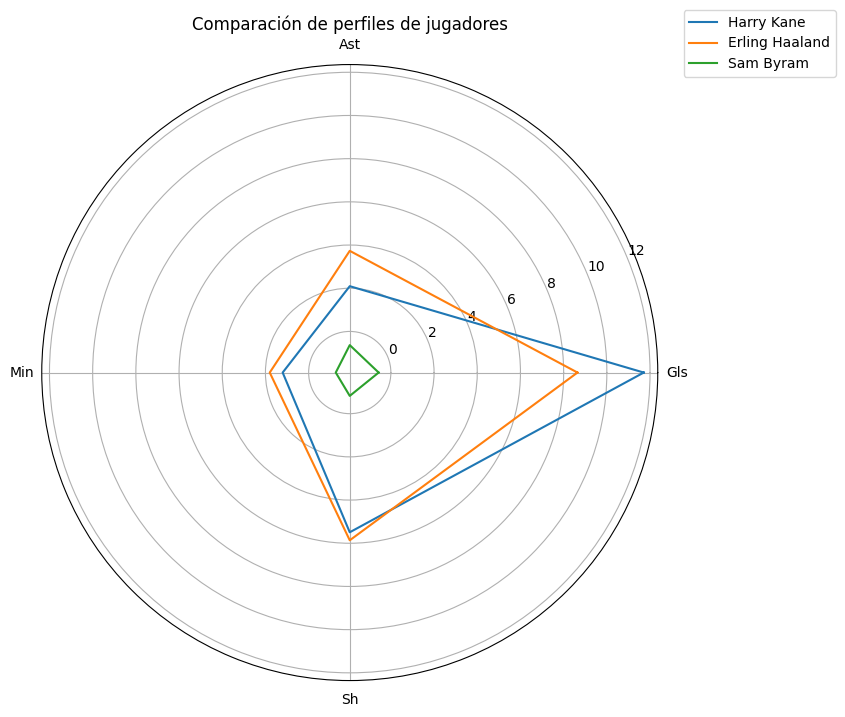

In [27]:
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

ax.plot(
    angulos,
    estrella_plot,
    label=df.loc[estrella, 'Player']
)

ax.plot(
    angulos,
    reeplazo_plot,
    label=df.loc[indice_reemplazo, 'Player']
)

ax.plot(
    angulos,
    random_plot,
    label=df.loc[random_index, 'Player']
)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(features)

ax.set_title("Comparación de perfiles de jugadores")

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1)
)

plt.show()